# Nadaraya-Watson

## 任务背景
假设我们有一组训练数据：包含 $n$ 个数据点 $(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$。
现在来了一个新的输入 $x$（这就是我们的 Query 查询），我们需要预测它对应的输出 $f(x)$

查询 (Query, $q$)：新的输入 $x$

键 (Key, $k_i$)：训练集里的输入 $x_i$

值 (Value, $v_i$)：训练集里的输出 $y_i$。

## 平均汇聚
最简单的方法就是把所有训练集的 $y_i$ 加起来求个平均值
$$f(x) = \frac{1}{n}\sum_{i=1}^n y_i$$
无论你的新查询 $x$ 是什么，它预测出来的结果都是一模一样的！这相当于“平等地对待环境中的每一个物品”，完全没有体现出“注意力”的选择性

## 加入注意力：非参数的 Nadaraya-Watson 核回归
1964 年，Nadaraya 和 Watson 提出了一个绝妙的想法：我们不要简单求平均了，我们根据查询 $x$ 和键 $x_i$ 的距离（相似度）来分配权重
$$f(x) = \sum_{i=1}^n \frac{K(x - x_i)}{\sum_{j=1}^n K(x - x_j)} y_i$$
这里的 $K$ 就是一个核函数，用来衡量 $x$ 和 $x_i$ 的相似度。分母的作用是做归一化，保证所有权重加起来等于 1

定义一个注意力权重 $\alpha(x, x_i)$
$$\alpha(x, x_i) = \frac{K(x - x_i)}{\sum_{j=1}^n K(x - x_j)}$$

那么预测结果就是所有的 Value ($y_i$) 乘以对应的注意力权重求和

$$f(x) = \sum_{i=1}^n \alpha(x, x_i) y_i$$

## 引入高斯核与 Softmax
为了让上面的公式真正可以计算，我们需要选定一个具体的核函数 $K$，最常用的就是高斯核
$$K(u) = \frac{1}{\sqrt{2\pi}} \exp(-\frac{u^2}{2})$$
把高斯核代入到刚才的注意力权重 $\alpha(x, x_i)$ 的公式里
$$\alpha(x, x_i) = \frac{\exp(-\frac{1}{2}(x - x_i)^2)}{\sum_{j=1}^n \exp(-\frac{1}{2}(x - x_j)^2)}$$
这就是深度学习里的 Softmax 操作
$$\alpha(x, x_i) = \text{softmax}\left(-\frac{1}{2}(x - x_i)^2\right)$$

## 参数化注意力模型
Nadaraya-Watson 核回归很完美，但它有一个致命缺点：它没有可以学习的参数！ 所有的权重都是根据数据的物理距离死算出来的，这叫“非参数模型”
$$\alpha(x, x_i) = \text{softmax}\left(-\frac{1}{2}((x - x_i)w)^2\right)$$
有了这个 $w$，神经网络就可以通过反向传播来自动学习：到底该如何衡量查询和键之间的距离，才能让预测结果最准

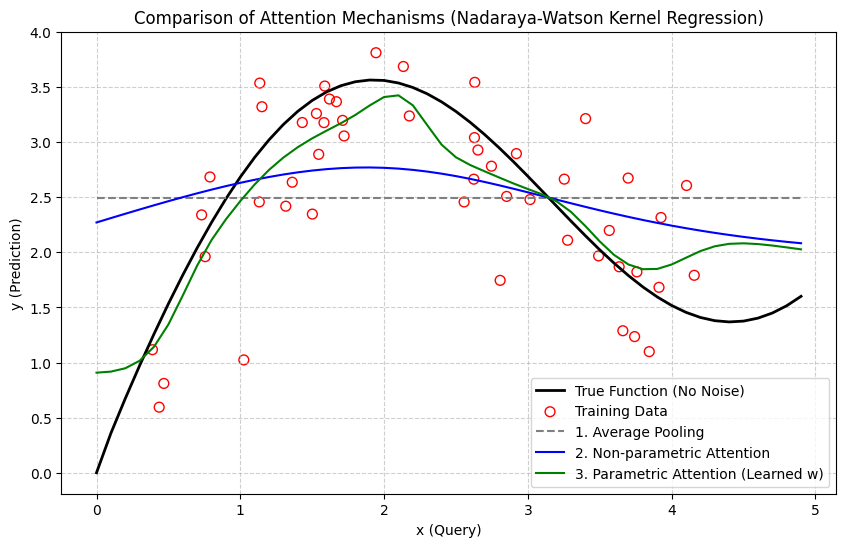

训练结束，模型学习到的参数 w = 4.6561


In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# 1. 数据准备与生成
n_train = 50  # 训练样本数
# 生成排序后的训练输入 x_train，范围大约在 [0, 5]
x_train, _ = torch.sort(torch.rand(n_train) * 5)

# 根据公式 y = 2*sin(x) + x^0.8 + 噪声 生成训练集标签
def f(x):
    return 2 * torch.sin(x) + x**0.8

# 生成带有高斯噪声的 y_train
y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))

# 生成测试用的查询点 x_test
x_test = torch.arange(0, 5, 0.1)
y_truth = f(x_test)  # 真实的无噪声曲线

# 2. 方法一：平均汇聚 (Average Pooling)
# 最基础的方法，完全不看查询 x，直接输出所有 y_train 的平均值
y_hat_avg = y_train.mean().repeat(len(x_test))

# 3. 方法二：非参数注意力汇聚
# 根据 Query (x_test) 和 Key (x_train) 的距离分配权重
# 利用广播机制，让每个测试点计算与所有训练点的距离
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# 计算高斯核注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# 权重矩阵乘以 Value (y_train) 得到预测值
y_hat_nonparam = torch.matmul(attention_weights, y_train)

# 4. 方法三：带参数注意力汇聚 
# 引入可学习的参数 w，控制注意力的高斯核宽度
class NWKernelRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

# 准备带参数模型的训练数据
X_tile = x_train.repeat((n_train, 1))
Y_tile = y_train.repeat((n_train, 1))
mask = (1 - torch.eye(n_train)).type(torch.bool)
keys = X_tile[mask].reshape((n_train, -1))
values = Y_tile[mask].reshape((n_train, -1))

net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)

# 训练循环 
for epoch in range(50):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()

# 用训练好的模型进行预测
# 注意：测试阶段 Query 是 x_test，Key 和 Value 是全部训练集
keys_test = x_train.repeat((len(x_test), 1))
values_test = y_train.repeat((len(x_test), 1))
y_hat_param = net(x_test, keys_test, values_test).detach()

# 5. 可视化对比
plt.figure(figsize=(10, 6))
# 绘制真实的曲线
plt.plot(x_test, y_truth, label='True Function (No Noise)', color='black', linewidth=2)
# 绘制散点（带噪声的训练数据）
plt.scatter(x_train, y_train, facecolors='none', edgecolors='red', s=50, label='Training Data')

# 绘制三种方法的拟合曲线
plt.plot(x_test, y_hat_avg, label='1. Average Pooling', linestyle='--', color='gray')
plt.plot(x_test, y_hat_nonparam, label='2. Non-parametric Attention', color='blue')
plt.plot(x_test, y_hat_param, label='3. Parametric Attention (Learned w)', color='green')

plt.xlabel('x (Query)')
plt.ylabel('y (Prediction)')
plt.title('Comparison of Attention Mechanisms (Nadaraya-Watson Kernel Regression)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 打印一下学习到的 w 参数
print(f"训练结束，模型学习到的参数 w = {net.w.data.item():.4f}")